In [143]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score , roc_curve
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier 
import matplotlib.pyplot as plt

In [96]:
sns.set_style("darkgrid", {"axes.facecolor": ".9"})

In [97]:
ds = pd.read_csv('train.csv',index_col = 'id')
ds.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
id,,,,,,,,,,,,,,,,,,,,
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85,No
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.5,3778.20,No
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.4,5841.35,No


In [98]:
for col in ds.select_dtypes(include='object').columns:
    ds[col] = ds[col].astype('category')
ds.info()

<class 'pandas.core.frame.DataFrame'>
Index: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   gender            594194 non-null  category
 1   SeniorCitizen     594194 non-null  int64   
 2   Partner           594194 non-null  category
 3   Dependents        594194 non-null  category
 4   tenure            594194 non-null  int64   
 5   PhoneService      594194 non-null  category
 6   MultipleLines     594194 non-null  category
 7   InternetService   594194 non-null  category
 8   OnlineSecurity    594194 non-null  category
 9   OnlineBackup      594194 non-null  category
 10  DeviceProtection  594194 non-null  category
 11  TechSupport       594194 non-null  category
 12  StreamingTV       594194 non-null  category
 13  StreamingMovies   594194 non-null  category
 14  Contract          594194 non-null  category
 15  PaperlessBilling  594194 non-null  category
 16  Payment

<Axes: xlabel='tenure', ylabel='Count'>

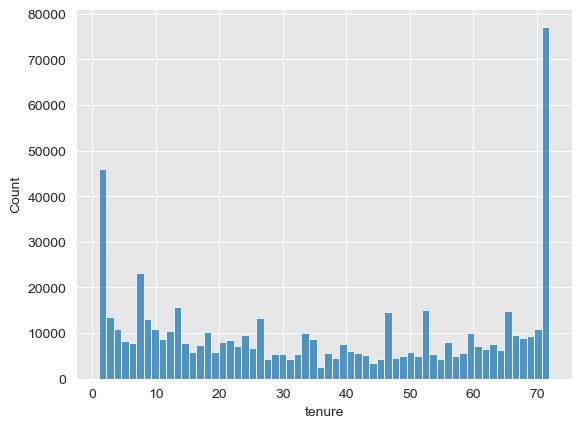

In [81]:
sns.histplot(ds['tenure']) 

In [42]:
ds['Contract'].unique()

array(['One year', 'Two year', 'Month-to-month'], dtype=object)

<Axes: xlabel='TotalCharges', ylabel='Count'>

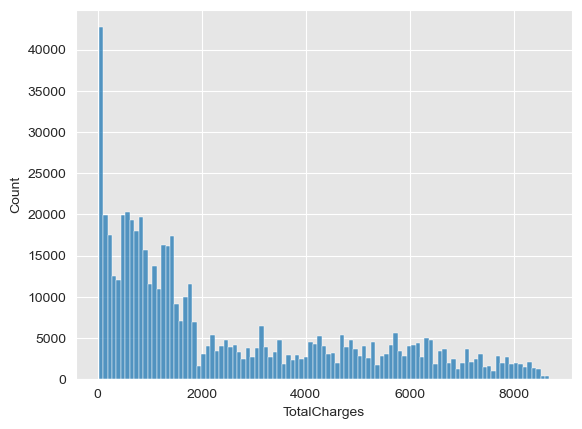

In [82]:
sns.histplot(ds['TotalCharges'])

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

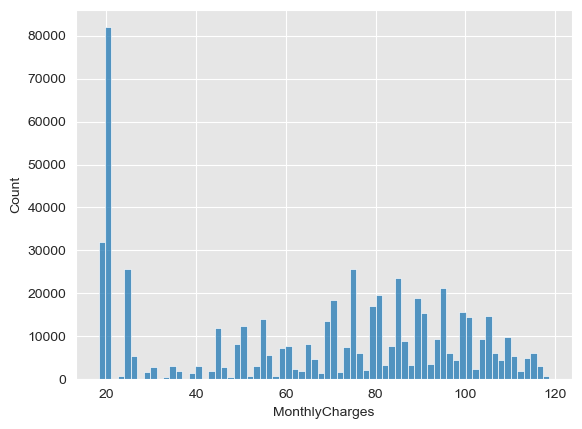

In [83]:
sns.histplot(ds['MonthlyCharges'])

<Axes: xlabel='TechSupport', ylabel='Count'>

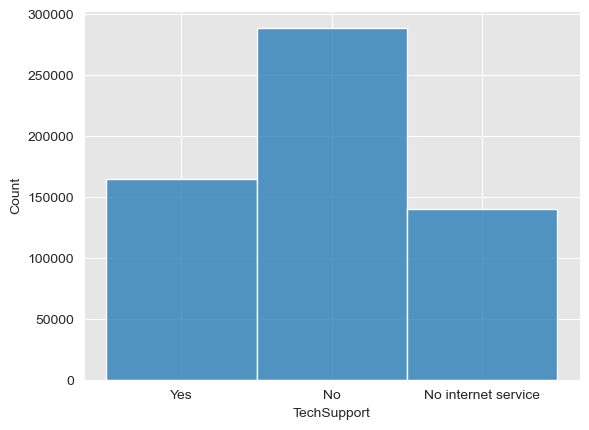

In [84]:
sns.histplot(ds['TechSupport'])

In [57]:
print(ds['TechSupport'].unique())

['Yes' 'No' 'No internet service']


In [59]:
A = (ds['Churn'].where(ds['TechSupport'] == 'Yes'))
print(A[A =='Yes'].count())
B = (ds['Churn'].where(ds['TechSupport'] == 'No'))
print(B[B =='Yes'].count())
C = (ds['Churn'].where(ds['TechSupport'] == 'No internet service'))
print(C[C =='Yes'].count())
print(ds['Churn'].where(ds['Churn']=='Yes').count())
print(ds['Churn'].where(ds['Churn']=='No').count())

15907
115896
2014
133817
460377


In [106]:
categorical_cols = ['gender','SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 
                    'MultipleLines', 'InternetService', 'OnlineSecurity', 
                    'OnlineBackup', 'DeviceProtection', 'TechSupport', 
                    'StreamingTV', 'StreamingMovies', 'Contract', 
                    'PaperlessBilling', 'PaymentMethod']
numeric_cols = [ 'tenure', 'MonthlyCharges', 'TotalCharges']
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough'
)

def create_pipeline(model):
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    return pipeline


In [107]:
X = ds.drop('Churn',axis = 1)
y = ds['Churn']
X_train, X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [130]:
tree = RandomForestClassifier(random_state=42, class_weight= "balanced")#DecisionTreeClassifier(random_state=42)
pipe = create_pipeline(tree)
pipe.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [131]:
y_pred = pipe.predict(X_test)
y_pred_proba = pipe.predict_proba(X_test)[:, 1] 
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC score: {roc_auc}")
print(y_pred)

ROC AUC score: 0.8949729658446419
['No' 'No' 'No' ... 'No' 'No' 'No']


In [139]:
cat =  CatBoostClassifier(random_state=42 ,loss_function='Logloss',eval_metric='AUC',cat_features=categorical_cols,class_weights={"No":1,"Yes":5})
cat.fit(X_train,y_train) 

Learning rate set to 0.143226
0:	total: 864ms	remaining: 14m 22s
1:	total: 1.6s	remaining: 13m 17s
2:	total: 2.63s	remaining: 14m 33s
3:	total: 3.52s	remaining: 14m 35s
4:	total: 4.58s	remaining: 15m 10s
5:	total: 5.69s	remaining: 15m 43s
6:	total: 6.49s	remaining: 15m 21s
7:	total: 7.38s	remaining: 15m 14s
8:	total: 8.08s	remaining: 14m 49s
9:	total: 8.96s	remaining: 14m 47s
10:	total: 9.82s	remaining: 14m 43s
11:	total: 10.4s	remaining: 14m 19s
12:	total: 11.2s	remaining: 14m 13s
13:	total: 11.9s	remaining: 14m 1s
14:	total: 12.6s	remaining: 13m 44s
15:	total: 13.2s	remaining: 13m 29s
16:	total: 13.8s	remaining: 13m 17s
17:	total: 14.5s	remaining: 13m 10s
18:	total: 15.1s	remaining: 12m 59s
19:	total: 15.8s	remaining: 12m 52s
20:	total: 16.3s	remaining: 12m 39s
21:	total: 17s	remaining: 12m 34s
22:	total: 17.6s	remaining: 12m 25s
23:	total: 18.3s	remaining: 12m 24s
24:	total: 19s	remaining: 12m 20s
25:	total: 19.8s	remaining: 12m 20s
26:	total: 20.5s	remaining: 12m 17s
27:	total: 21.

CatBoostClassifier(cat_features=['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'], class_weights={'No': 1, 'Yes': 5}, eval_metric='AUC', loss_function='Logloss', random_state=42)

In [146]:
y_pred = cat.predict(X_test)
y_pred_proba = cat.predict_proba(X_test)[:, 1] 
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba, pos_label='Yes')
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC score: {roc_auc}")

ROC AUC score: 0.9166987235047142
['No' 'No' 'No' ... 'Yes' 'Yes' 'Yes']


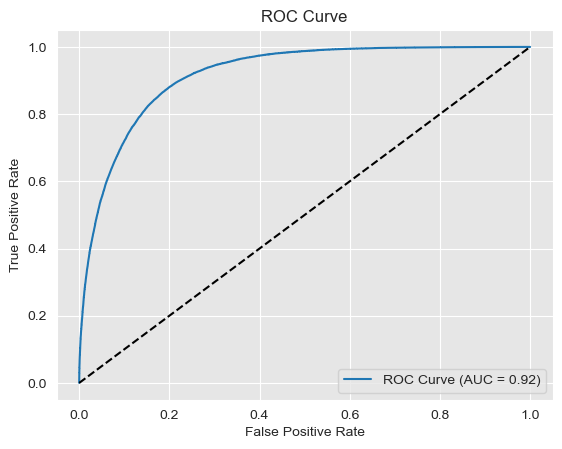

In [149]:
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Случайная модель
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig(fname='ROC-Curve')
plt.show()